In [22]:
#Setup the libraries
!pip install imbalanced-learn xgboost -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import os

os.makedirs("/content/phase3_output", exist_ok=True)
print("All libraries loaded")

All libraries loaded


In [4]:
#Loading data
df = pd.read_csv("/content/cleaned_diabetes_data (1).csv")
print(f"Shape: {df.shape}")
print("\nClass distribution:")
print(df["Diabetes_012"].value_counts())

Shape: (229772, 22)

Class distribution:
Diabetes_012
0    190046
2     35097
1      4629
Name: count, dtype: int64


In [5]:

#Feature engineering and split
df["GenHlth_Income"] = df["GenHlth"] * df["Income"]

X = df.drop(columns=["Diabetes_012"])
y = df["Diabetes_012"]


scaler = StandardScaler()
cols_to_scale = ["BMI", "MentHlth", "PhysHlth"]
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("\nTrain class distribution:")
print(y_train.value_counts())

Train: (183817, 22) | Test: (45955, 22)

Train class distribution:
Diabetes_012
0    152036
2     28078
1      3703
Name: count, dtype: int64


In [6]:
#Applying SMOTE to prevent data leakage
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Class distribution after SMOTE:
Diabetes_012
0    152036
2    152036
1    152036
Name: count, dtype: int64


In [7]:
# 5 fold Cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Defining base models
models_cv = {
    "Logistic Regression": LogisticRegression(
        multi_class="multinomial", max_iter=1000,
        class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softprob", num_class=3,
        eval_metric="mlogloss", use_label_encoder=False,
        random_state=42, n_jobs=-1
    )
}

scoring = ["accuracy", "f1_weighted", "roc_auc_ovr_weighted"]

print("Running 5-Fold Cross-Validation...\n")
cv_results = {}

for name, model in models_cv.items():
    print(f"  → {name}...")
    scores = cross_validate(
        model, X_train_sm, y_train_sm,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    cv_results[name] = {
        "CV Accuracy":  scores["test_accuracy"].mean(),
        "CV F1":        scores["test_f1_weighted"].mean(),
        "CV ROC-AUC":   scores["test_roc_auc_ovr_weighted"].mean(),
        "F1 Std":       scores["test_f1_weighted"].std()
    }
    print(f"     Accuracy={cv_results[name]['CV Accuracy']:.4f}  "
          f"F1={cv_results[name]['CV F1']:.4f}  "
          f"ROC-AUC={cv_results[name]['CV ROC-AUC']:.4f}  "
          f"(±{cv_results[name]['F1 Std']:.4f})\n")

cv_df = pd.DataFrame(cv_results).T
print("\n 5-FOLD CROSS-VALIDATION SUMMARY")
print(cv_df.round(4).to_string())

Running 5-Fold Cross-Validation...

  → Logistic Regression...
     Accuracy=0.5467  F1=0.5459  ROC-AUC=0.7393  (±0.0022)

  → Random Forest...
     Accuracy=0.9027  F1=0.9024  ROC-AUC=0.9788  (±0.0010)

  → XGBoost...
     Accuracy=0.7586  F1=0.7523  ROC-AUC=0.9052  (±0.0021)


 5-FOLD CROSS-VALIDATION SUMMARY
                     CV Accuracy   CV F1  CV ROC-AUC  F1 Std
Logistic Regression       0.5467  0.5459      0.7393  0.0022
Random Forest             0.9027  0.9024      0.9788  0.0010
XGBoost                   0.7586  0.7523      0.9052  0.0021


In [9]:
#Hyperparameter tuning
print("Running GridSearchCV on Random Forest (optimized)...")

param_grid = {
    "n_estimators": [100],
    "max_depth":    [10, 20],
    "min_samples_split": [2, 5],
    "class_weight": ["balanced"]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=2,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

from sklearn.utils import resample
X_gs, y_gs = resample(
    X_train_sm, y_train_sm,
    n_samples=40000,
    random_state=42,
    stratify=y_train_sm
)

grid_search.fit(X_gs, y_gs)

print(f"\n✓ Best Parameters: {grid_search.best_params_}")
print(f"✓ Best CV F1 Score: {grid_search.best_score_:.4f}")

rf_best = grid_search.best_estimator_

rf_best.fit(X_train_sm, y_train_sm)
print("✓ Refitted best RF on full training data")

Running GridSearchCV on Random Forest (optimized)...
Fitting 2 folds for each of 4 candidates, totalling 8 fits

✓ Best Parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
✓ Best CV F1 Score: 0.7233
✓ Refitted best RF on full training data


In [10]:
# Model training
#Logistic Regression
lr = LogisticRegression(
    multi_class="multinomial", max_iter=1000,
    class_weight="balanced", random_state=42
)
lr.fit(X_train_sm, y_train_sm)
print("✓ Logistic Regression trained")

# Random Forest
rf_best.fit(X_train_sm, y_train_sm)
print("✓ Random Forest (tuned) trained")

# XGBoost
xgb = XGBClassifier(
    objective="multi:softprob", num_class=3,
    n_estimators=200, max_depth=6,
    learning_rate=0.1, subsample=0.8,
    eval_metric="mlogloss", use_label_encoder=False,
    random_state=42, n_jobs=-1
)
xgb.fit(X_train_sm, y_train_sm)
print("✓ XGBoost trained")

✓ Logistic Regression trained
✓ Random Forest (tuned) trained
✓ XGBoost trained


In [11]:
#moDel evaluation
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    metrics = {
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall":    recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1":        f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted")
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    for k, v in metrics.items():
        if k != "Model":
            print(f"  {k:<12}: {v:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=["No Diabetes", "Pre-Diabetes", "Diabetes"]
    ))
    return metrics

r_lr  = evaluate_model(lr,      X_test, y_test, "Logistic Regression")
r_rf  = evaluate_model(rf_best, X_test, y_test, "Random Forest (Tuned)")
r_xgb = evaluate_model(xgb,     X_test, y_test, "XGBoost")

comparison_df = pd.DataFrame([r_lr, r_rf, r_xgb]).set_index("Model")
print("\n\n📊 FINAL MODEL COMPARISON TABLE")
print(comparison_df.round(4).to_string())


  Logistic Regression
  Accuracy    : 0.6152
  Precision   : 0.8190
  Recall      : 0.6152
  F1          : 0.6881
  ROC-AUC     : 0.7533

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.92      0.63      0.75     38010
Pre-Diabetes       0.02      0.21      0.04       926
    Diabetes       0.36      0.60      0.45      7019

    accuracy                           0.62     45955
   macro avg       0.44      0.48      0.41     45955
weighted avg       0.82      0.62      0.69     45955


  Random Forest (Tuned)
  Accuracy    : 0.7469
  Precision   : 0.8022
  Recall      : 0.7469
  F1          : 0.7690
  ROC-AUC     : 0.7699

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.90      0.80      0.85     38010
Pre-Diabetes       0.03      0.05      0.04       926
    Diabetes       0.37      0.56      0.45      7019

    accuracy                           0.75     45955
   macro avg       0.

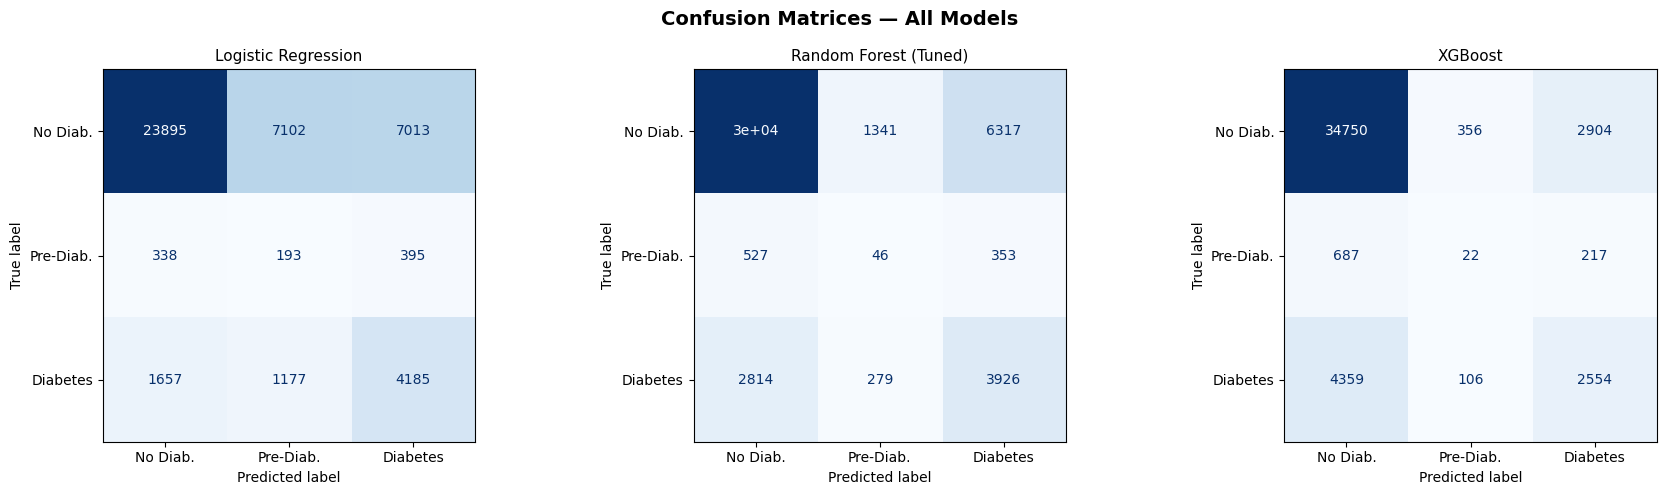

✓ Saved confusion_matrices.png


In [12]:
#confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")

for ax, model, name in zip(
    axes,
    [lr, rf_best, xgb],
    ["Logistic Regression", "Random Forest (Tuned)", "XGBoost"]
):
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(
        cm, display_labels=["No Diab.", "Pre-Diab.", "Diabetes"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.savefig("/content/phase3_output/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved confusion_matrices.png")

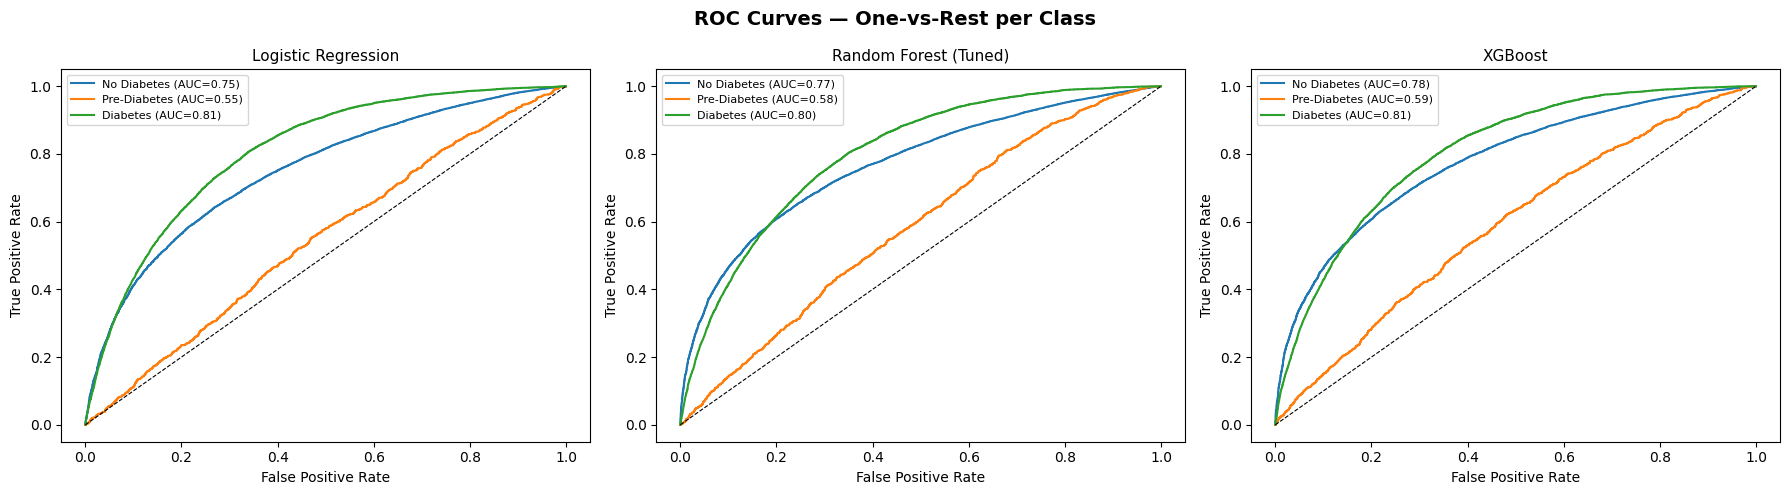

✓ Saved roc_curves.png


In [13]:
#ROC Curves
class_names = ["No Diabetes", "Pre-Diabetes", "Diabetes"]
y_test_bin  = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ROC Curves — One-vs-Rest per Class", fontsize=14, fontweight="bold")

for ax, model, name in zip(
    axes,
    [lr, rf_best, xgb],
    ["Logistic Regression", "Random Forest (Tuned)", "XGBoost"]
):
    y_prob = model.predict_proba(X_test)
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{cls_name} (AUC={roc_auc:.2f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/content/phase3_output/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved roc_curves.png")

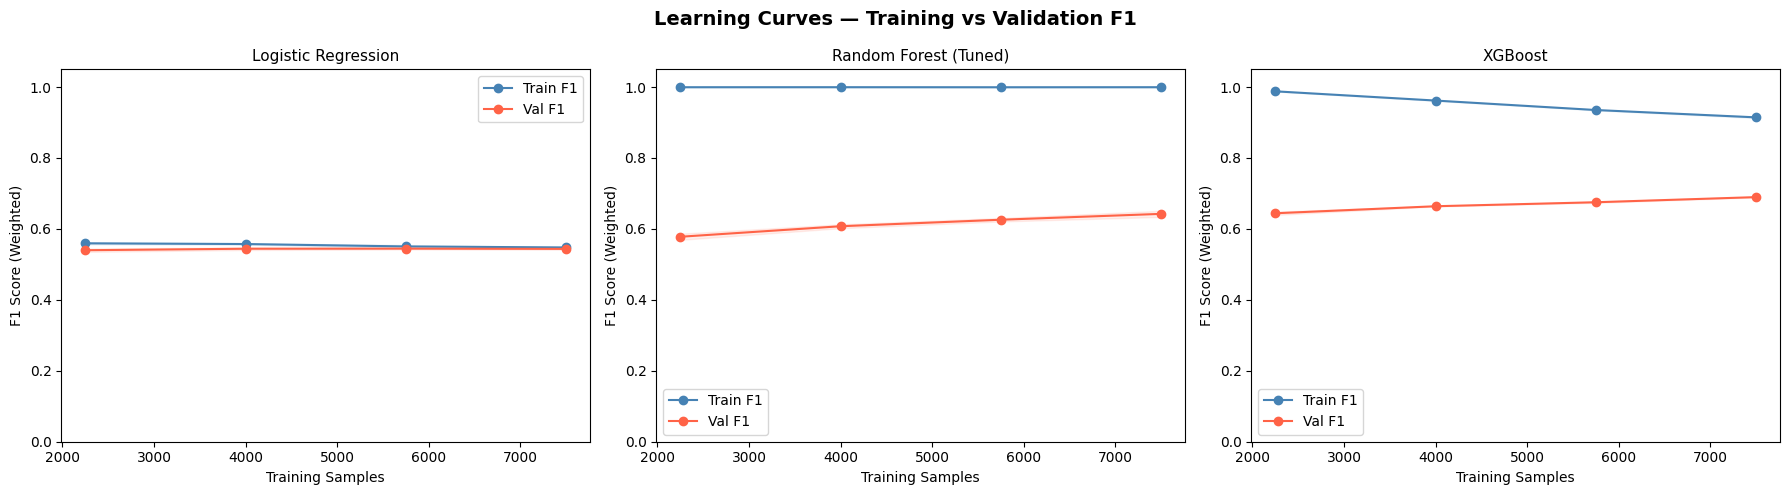

✓ Saved learning_curves.png


In [14]:
#Learning curves
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Learning Curves — Training vs Validation F1", fontsize=14, fontweight="bold")

sample_idx = np.random.choice(len(X_train_sm), size=15000, replace=False)
X_lc = X_train_sm.iloc[sample_idx]
y_lc = y_train_sm.iloc[sample_idx]

for ax, model, name in zip(
    axes,
    [lr, rf_best, xgb],
    ["Logistic Regression", "Random Forest (Tuned)", "XGBoost"]
):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_lc, y_lc,
        cv=2,                                    # 2 folds instead of 3
        scoring="f1_weighted",
        train_sizes=np.linspace(0.3, 1.0, 4),   # 4 points instead of 5
        n_jobs=-1
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train F1", color="steelblue")
    ax.plot(train_sizes, val_scores.mean(axis=1),   "o-", label="Val F1",   color="tomato")
    ax.fill_between(train_sizes,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.1, color="steelblue")
    ax.fill_between(train_sizes,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1),
                    alpha=0.1, color="tomato")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("F1 Score (Weighted)")
    ax.legend()
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("/content/phase3_output/learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved learning_curves.png")

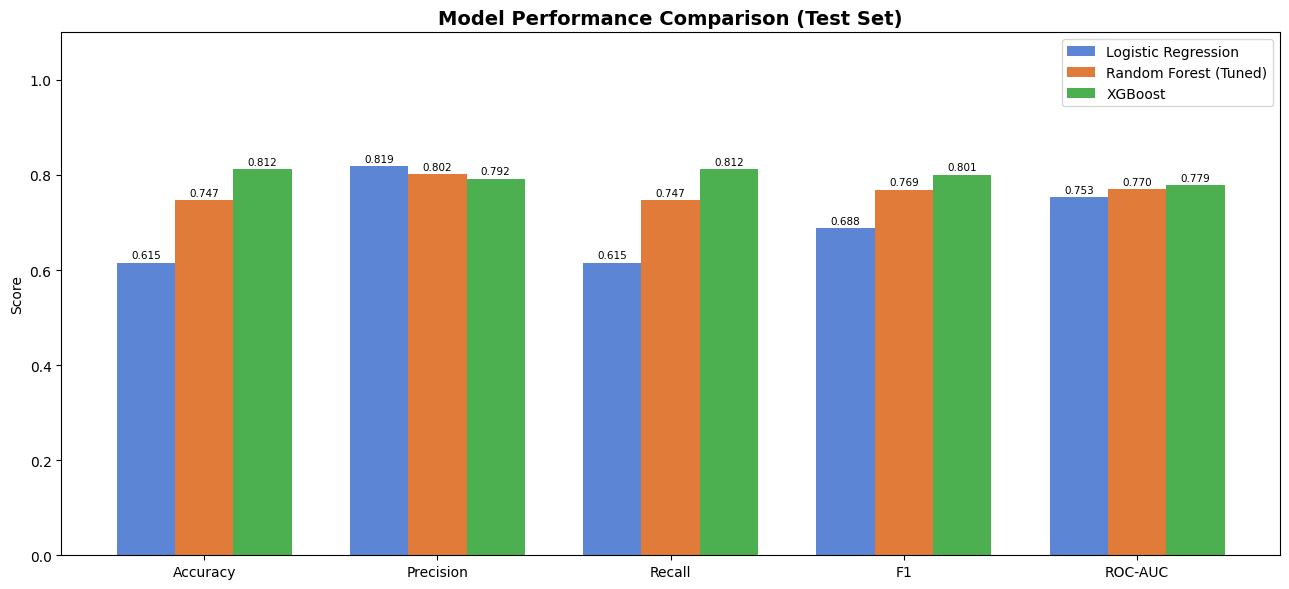

✓ Saved model_comparison.png


In [15]:
#Learning Curves
metrics_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
x     = np.arange(len(metrics_plot))
width = 0.25
colors = ["#5C85D6", "#E07B39", "#4CAF50"]

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model_name, color) in enumerate(zip(comparison_df.index, colors)):
    bars = ax.bar(
        x + i * width,
        comparison_df.loc[model_name, metrics_plot],
        width, label=model_name, color=color
    )
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=7.5)

ax.set_ylim(0, 1.1)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_plot)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison (Test Set)", fontsize=14, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("/content/phase3_output/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved model_comparison.png")

In [16]:
#Model comparison
print("=" * 55)
print("  PRE-DIABETES CLASS ANALYSIS")
print("=" * 55)

for model, name in [(lr, "Logistic Regression"),
                    (rf_best, "Random Forest (Tuned)"),
                    (xgb, "XGBoost")]:
    y_pred = model.predict(X_test)
    report = classification_report(
        y_test, y_pred,
        target_names=["No Diabetes", "Pre-Diabetes", "Diabetes"],
        output_dict=True
    )
    pre_f1     = report["Pre-Diabetes"]["f1-score"]
    pre_recall = report["Pre-Diabetes"]["recall"]
    print(f"\n  {name}")
    print(f"    Pre-Diabetes F1     : {pre_f1:.4f}")
    print(f"    Pre-Diabetes Recall : {pre_recall:.4f}")


  PRE-DIABETES CLASS ANALYSIS

  Logistic Regression
    Pre-Diabetes F1     : 0.0411
    Pre-Diabetes Recall : 0.2084

  Random Forest (Tuned)
    Pre-Diabetes F1     : 0.0355
    Pre-Diabetes Recall : 0.0497

  XGBoost
    Pre-Diabetes F1     : 0.0312
    Pre-Diabetes Recall : 0.0238


In [20]:
#Best Model
best_model_name = comparison_df["F1"].idxmax()
best_roc        = comparison_df.loc[best_model_name, "ROC-AUC"]
best_f1         = comparison_df.loc[best_model_name, "F1"]

print(" Full Comparison:")
print(comparison_df.round(4).to_string())

 Full Comparison:
                       Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                              
Logistic Regression      0.6152     0.8190  0.6152  0.6881   0.7533
Random Forest (Tuned)    0.7469     0.8022  0.7469  0.7690   0.7699
XGBoost                  0.8122     0.7919  0.8122  0.8009   0.7789
